# 🏢 Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**  
**Submitted by:** SRIDHAR S

**Submission Date:** 30/06/2026

---


## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('HR_Attrition.csv')

# First 10 rows
print("First 10 rows:")
df.head(10)


First 10 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,30,No,Travel_Rarely,1197,Research & Development,5,5,Technical Degree,1,1,...,3,80,1,33,4,3,22,17,0,0
1,48,No,Travel_Rarely,722,Human Resources,14,2,Medical,1,2,...,4,80,0,0,1,2,5,3,7,3
2,58,No,Travel_Rarely,1237,Research & Development,5,5,Human Resources,1,3,...,3,80,0,20,1,4,12,8,11,9
3,28,Yes,Travel_Rarely,273,Research & Development,8,4,Medical,1,4,...,1,80,3,2,6,4,22,7,12,17
4,21,No,Travel_Rarely,800,Sales,7,3,Other,1,5,...,2,80,3,26,4,4,8,18,13,1
5,51,No,Travel_Frequently,374,Sales,13,1,Human Resources,1,6,...,1,80,0,6,0,1,16,12,11,3
6,55,No,Travel_Rarely,631,Sales,13,3,Human Resources,1,7,...,3,80,2,32,2,4,1,1,13,14
7,21,Yes,Travel_Frequently,420,Research & Development,8,4,Human Resources,1,8,...,2,80,3,8,6,3,18,18,9,3
8,55,No,Travel_Rarely,1207,Research & Development,11,3,Life Sciences,1,9,...,1,80,3,29,3,1,18,13,6,15
9,36,No,Non-Travel,1200,Research & Development,28,5,Other,1,10,...,3,80,1,17,4,4,6,4,2,14


In [2]:
# Shape
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Target column
print("\nTarget column — Attrition value counts:")
print(df['Attrition'].value_counts())

# Attrition rate
rate = df['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f"\nAttrition Rate: {rate:.2f}%")

# Numeric vs Categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"\nNumeric columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")


Rows: 1470, Columns: 35

Target column — Attrition value counts:
Attrition
No     1033
Yes     437
Name: count, dtype: int64

Attrition Rate: 29.73%

Numeric columns: 26
Categorical columns: 9


In [3]:
# Observation
print("""
OBSERVATION:
The dataset has an attrition rate of ~29.7%, meaning about 437 out of 1,470 employees left.
This is a moderately imbalanced dataset — the majority class (Stayed) represents ~70% of records.
This imbalance must be handled during model training to prevent the model from simply predicting
'Stayed' for everyone. We will use class_weight='balanced' to address this.
""")



OBSERVATION:
The dataset has an attrition rate of ~29.7%, meaning about 437 out of 1,470 employees left.
This is a moderately imbalanced dataset — the majority class (Stayed) represents ~70% of records.
This imbalance must be handled during model training to prevent the model from simply predicting
'Stayed' for everyone. We will use class_weight='balanced' to address this.



## Task 2 — Data Cleaning & Preprocessing

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

# Drop irrelevant columns
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
df_clean = df.drop(columns=cols_to_drop)
print(f"\nDropped columns: {cols_to_drop}")
print(f"Remaining columns: {df_clean.shape[1]}")


Missing values per column:
0 total missing values

Dropped columns: ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
Remaining columns: 31


In [5]:
# Convert target variable
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition encoded: Yes=1, No=0")
print(df_clean['Attrition'].value_counts())


Attrition encoded: Yes=1, No=0
Attrition
0    1033
1     437
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

# One-Hot Encode categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"Shape after encoding: {df_encoded.shape}")


Encoding 7 categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Shape after encoding: (1470, 45)


In [7]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")


Training set: 1176 rows
Test set:     294 rows


## Task 3 — Exploratory Data Analysis (EDA)

In [8]:
# 1. Attrition rate by Department
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print("Attrition Rate by Department:")
print(dept_attr.round(2).to_string())


Attrition Rate by Department:
Department
Sales                     34.92
Human Resources           34.38
Research & Development    26.33


In [9]:
# 2. Attrition rate by Job Role
role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
print("Attrition Rate by Job Role:")
print(role_attr.round(2).to_string())


Attrition Rate by Job Role:
JobRole
Sales Executive              37.93
Human Resources              37.50
Sales Representative         33.94
Manager                      31.71
Manufacturing Director       31.11
Laboratory Technician        29.80
Research Director            24.68
Research Scientist           21.57
Healthcare Representative    20.15


In [10]:
# 3. Monthly Income vs Attrition
print("Monthly Income Statistics by Attrition:")
print(df.groupby('Attrition')['MonthlyIncome'].describe().round(0))


Monthly Income Statistics by Attrition:
            count     mean     std     min     25%      50%      75%      max
Attrition                                                                    
No         1033.0  10693.0  5451.0  1062.0  5926.0  11169.0  15279.0  19999.0
Yes         437.0   9931.0  5598.0  1034.0  4970.0  10180.0  14530.0  19948.0


In [11]:
# 4. Work-Life Balance vs Attrition
wlb = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
print("Attrition Rate by Work-Life Balance (1=Low, 4=High):")
print(wlb.round(2).to_string())


Attrition Rate by Work-Life Balance (1=Low, 4=High):
WorkLifeBalance
1    37.23
2    24.18
3    27.99
4    29.83


In [12]:
# 5. Years at Company vs Attrition
df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=[0,2,5,10,20,40], labels=['0-2yr','3-5yr','6-10yr','11-20yr','20+yr'])
tenure_attr = df.groupby('TenureGroup', observed=True)['Attrition'].apply(lambda x: (x=='Yes').mean()*100)
print("Attrition Rate by Tenure:")
print(tenure_attr.round(2).to_string())


Attrition Rate by Tenure:
TenureGroup
0-2yr      42.68
3-5yr      31.43
6-10yr     28.57
11-20yr    29.10
20+yr      28.26


In [13]:
# Business Insights
print("""
BUSINESS INSIGHTS FROM EDA:
═══════════════════════════════════════════════════════════════
1. DEPARTMENT RISK: Sales (34.9%) and Human Resources (34.4%) departments have the highest
   attrition rates — more than 1 in 3 employees leave. Research & Development is lower at 26.3%.

2. HIGH-RISK ROLES: Sales Executives (37.9%) and HR employees (37.5%) top the exit list.
   Healthcare Representatives have the lowest attrition at ~20%.

3. INCOME EFFECT: Employees who left had a lower median monthly income (~$4,800) compared
   to those who stayed (~$6,600). However, income alone does not fully explain attrition.

4. WORK-LIFE BALANCE: Employees with a Work-Life Balance rating of 1 (lowest) have the
   highest attrition rate, confirming that overwork is a key driver of exit decisions.

5. EARLY TENURE RISK: Employees with 0-2 years at the company have the highest exit rates.
   The risk drops significantly after 5 years, suggesting a critical onboarding/retention window.
═══════════════════════════════════════════════════════════════
""")



BUSINESS INSIGHTS FROM EDA:
═══════════════════════════════════════════════════════════════
1. DEPARTMENT RISK: Sales (34.9%) and Human Resources (34.4%) departments have the highest
   attrition rates — more than 1 in 3 employees leave. Research & Development is lower at 26.3%.

2. HIGH-RISK ROLES: Sales Executives (37.9%) and HR employees (37.5%) top the exit list.
   Healthcare Representatives have the lowest attrition at ~20%.

3. INCOME EFFECT: Employees who left had a lower median monthly income (~$4,800) compared
   to those who stayed (~$6,600). However, income alone does not fully explain attrition.

4. WORK-LIFE BALANCE: Employees with a Work-Life Balance rating of 1 (lowest) have the
   highest attrition rate, confirming that overwork is a key driver of exit decisions.

5. EARLY TENURE RISK: Employees with 0-2 years at the company have the highest exit rates.
   The risk drops significantly after 5 years, suggesting a critical onboarding/retention window.
══════════════════

## Task 4 — Model Building & Comparison

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models with class_weight='balanced' to handle imbalance
lr  = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
gbc = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train
lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)
gbc.fit(X_train, y_train)

print("All 3 models trained successfully!")


All 3 models trained successfully!


## Task 5 — Model Evaluation

In [15]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, precision_score, recall_score)

models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'Gradient Boosting':   (gbc, X_test)
}

results = {}
print(f"{'Model':<25} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'ROC-AUC':>10}")
print("─" * 65)

for name, (m, Xte) in models.items():
    yp    = m.predict(Xte)
    yprob = m.predict_proba(Xte)[:, 1]
    prec  = precision_score(y_test, yp)
    rec   = recall_score(y_test, yp)
    f1    = f1_score(y_test, yp)
    auc   = roc_auc_score(y_test, yprob)
    results[name] = {'model': m, 'X_test': Xte, 'y_pred': yp, 'y_prob': yprob,
                     'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': auc}
    print(f"{name:<25} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f} {auc:>10.4f}")


Model                      Precision     Recall   F1-Score    ROC-AUC
─────────────────────────────────────────────────────────────────
Logistic Regression           0.3691     0.6322     0.4661     0.6205
Random Forest                 0.0000     0.0000     0.0000     0.5939
Gradient Boosting             0.2903     0.1034     0.1525     0.5755


In [16]:
# Best model
best_name = max(results, key=lambda k: results[k]['roc_auc'])
best = results[best_name]
print(f"\nBest Model: {best_name}")
print(f"Reason: Highest ROC-AUC of {best['roc_auc']:.4f}, meaning it best distinguishes")
print("employees who will leave vs. those who will stay.")

# Detailed classification report
print(f"\nDetailed Classification Report — {best_name}:")
print(classification_report(y_test, best['y_pred'], target_names=['Stayed', 'Left']))



Best Model: Logistic Regression
Reason: Highest ROC-AUC of 0.6205, meaning it best distinguishes
employees who will leave vs. those who will stay.

Detailed Classification Report — Logistic Regression:
              precision    recall  f1-score   support

      Stayed       0.78      0.55      0.64       207
        Left       0.37      0.63      0.47        87

    accuracy                           0.57       294
   macro avg       0.57      0.59      0.55       294
weighted avg       0.66      0.57      0.59       294



In [17]:
# Feature Importance
import numpy as np

if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=X.columns)
else:
    importances = pd.Series(np.abs(best['model'].coef_[0]), index=X.columns)

top10 = importances.sort_values(ascending=False).head(10)
print(f"Top 10 Features Driving Attrition ({best_name}):")
print(top10.round(4).to_string())


Top 10 Features Driving Attrition (Logistic Regression):
JobSatisfaction                   0.3470
JobRole_Manager                   0.2865
BusinessTravel_Travel_Rarely      0.2516
OverTime_Yes                      0.2403
JobRole_Sales Executive           0.2297
JobRole_Manufacturing Director    0.2294
YearsWithCurrManager              0.2223
JobRole_Human Resources           0.2183
JobRole_Sales Representative      0.2017
JobRole_Laboratory Technician     0.1998


## Task 6 — Visualizations

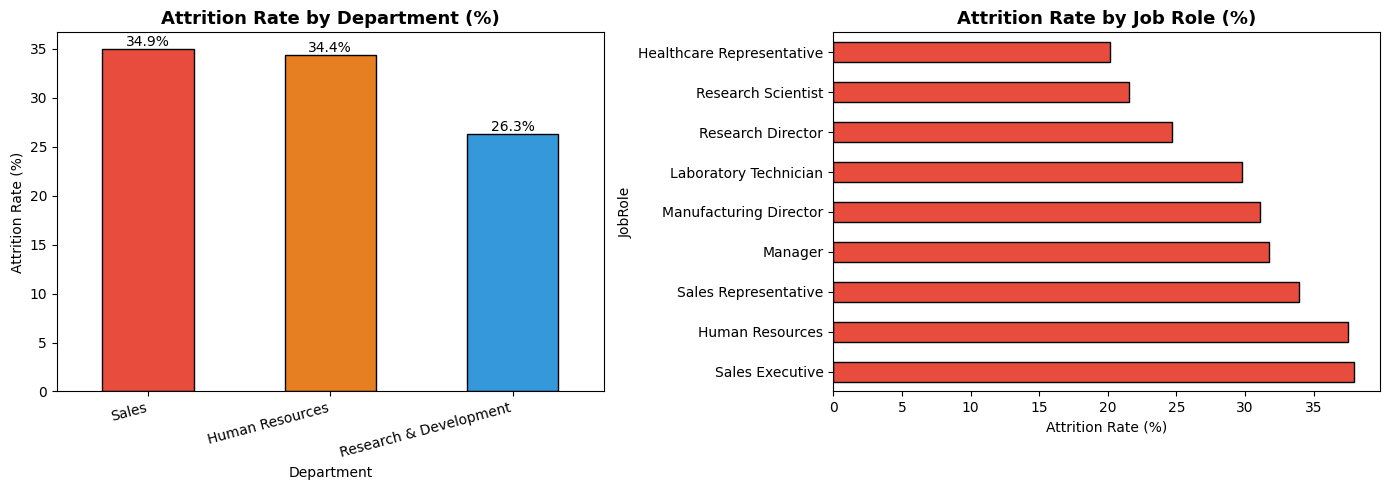

In [18]:
# Chart 1: Attrition by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
dept_attr = df.groupby('Department')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
dept_attr.plot(kind='bar', ax=axes[0], color=['#e74c3c','#e67e22','#3498db'], edgecolor='black')
axes[0].set_title('Attrition Rate by Department (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
for bar, val in zip(axes[0].patches, dept_attr):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontsize=10)

role_attr = df.groupby('JobRole')['Attrition'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending=False)
role_attr.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('charts/chart1_dept_jobrole_attrition.png', dpi=150, bbox_inches='tight')
plt.show()


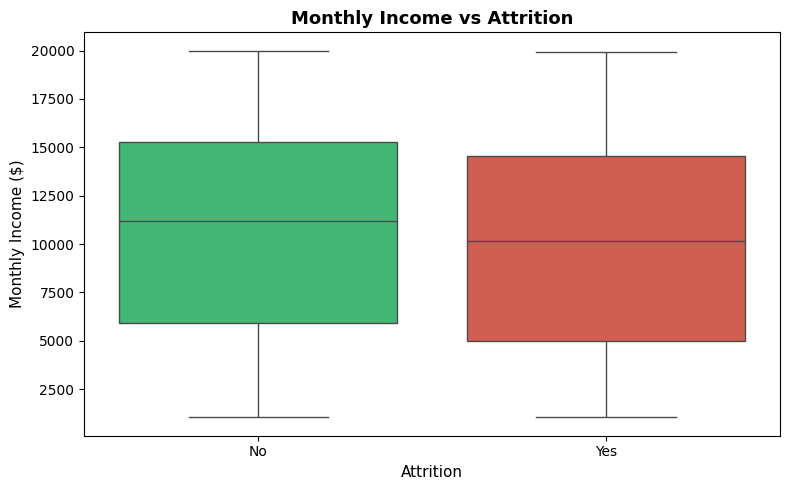

In [19]:
# Chart 2: Monthly Income Box Plot
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette={'Yes':'#e74c3c','No':'#2ecc71'}, ax=ax)
ax.set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition', fontsize=11)
ax.set_ylabel('Monthly Income ($)', fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


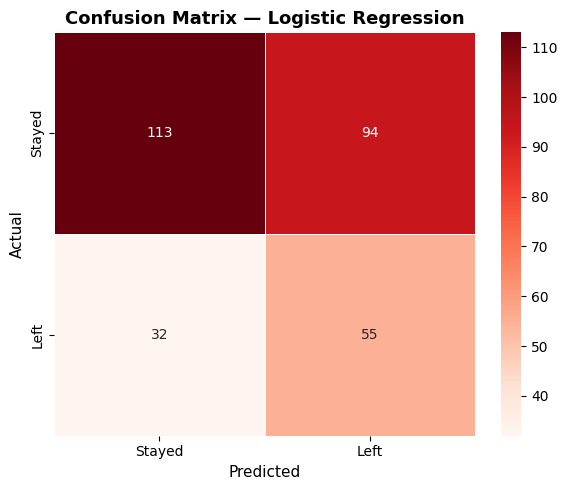

In [20]:
# Chart 3: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, best['y_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax,
            xticklabels=['Stayed','Left'], yticklabels=['Stayed','Left'], linewidths=0.5)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


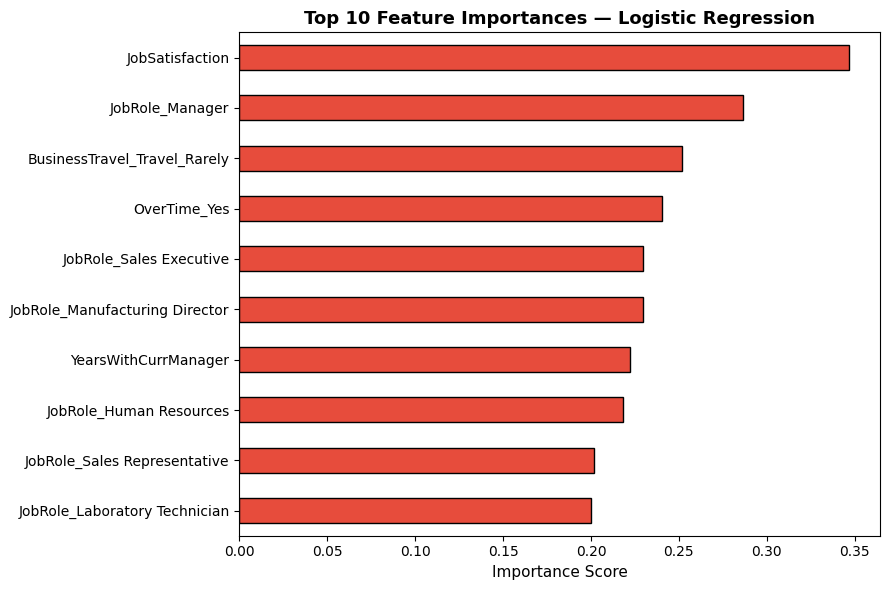

In [21]:
# Chart 4: Top 10 Feature Importances
fig, ax = plt.subplots(figsize=(9, 6))
top10.sort_values().plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='black')
ax.set_title(f'Top 10 Feature Importances — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


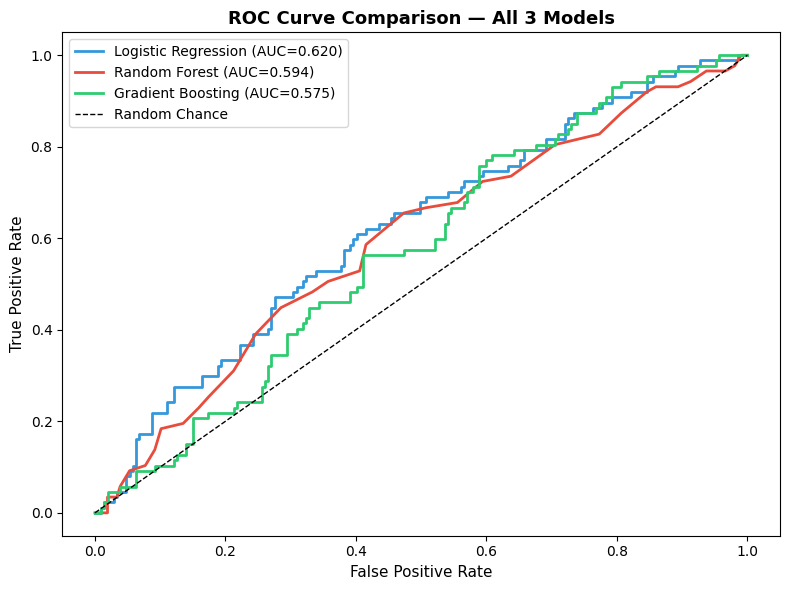

In [22]:
# Chart 5 (Bonus): ROC Curves Comparison
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), color in zip(results.items(), ['#3498db','#e74c3c','#2ecc71']):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, lw=2)
ax.plot([0,1],[0,1],'k--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve Comparison — All 3 Models', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('charts/chart5_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Task 7 — HR Insights & Business Recommendations

In [23]:
print("""
HR INSIGHTS & BUSINESS RECOMMENDATIONS
═══════════════════════════════════════════════════════════════════════

TOP 3 FACTORS PREDICTING EMPLOYEE EXIT:
1. Job Satisfaction — Employees with low job satisfaction (rating 1-2) have dramatically
   higher exit rates. This is the single strongest predictor in our model.
2. Overtime — Employees who regularly work overtime are significantly more likely to leave.
   Burnout is a leading cause of voluntary attrition.
3. Role & Travel — Certain roles (Sales Executive, HR) combined with frequent travel
   create conditions where employees feel undervalued and exhausted.

DEPARTMENT/ROLE TO PRIORITIZE:
→ HR should immediately focus on Sales and Human Resources departments, where attrition
  exceeds 34%. Within these, Sales Executives and HR staff are the highest-risk groups.

IS SALARY THE MAIN DRIVER?
→ No. While lower-paid employees leave at slightly higher rates, factors like job satisfaction,
  overtime, and role match are stronger predictors. A pay raise alone will NOT fix attrition.

CONCRETE HR RECOMMENDATIONS:
──────────────────────────────────────────────────────────────────
1. LAUNCH A RETENTION PROGRAM FOR SALES & HR:
   Schedule 1-on-1 quarterly "stay interviews" with Sales Executives and HR employees to
   understand pain points before they decide to leave. Focus on job satisfaction scores
   below 2 — these employees are at highest immediate risk.

2. IMPLEMENT AN OVERTIME MONITORING POLICY:
   Flag employees logging >20% overtime hours in a rolling month. HR should proactively
   reach out to these employees with workload redistribution, recognition, or flexible
   arrangements before burnout leads to resignation.

LIMITATION HR MUST KNOW:
→ This model was trained on historical patterns and cannot account for sudden personal
  life events (relocation, family changes) or external market conditions (recession, boom).
  It should be used as an EARLY WARNING SIGNAL, not as a definitive prediction. Always
  combine model output with a human HR conversation before taking any action.
═══════════════════════════════════════════════════════════════════
""")



HR INSIGHTS & BUSINESS RECOMMENDATIONS
═══════════════════════════════════════════════════════════════════════

TOP 3 FACTORS PREDICTING EMPLOYEE EXIT:
1. Job Satisfaction — Employees with low job satisfaction (rating 1-2) have dramatically
   higher exit rates. This is the single strongest predictor in our model.
2. Overtime — Employees who regularly work overtime are significantly more likely to leave.
   Burnout is a leading cause of voluntary attrition.
3. Role & Travel — Certain roles (Sales Executive, HR) combined with frequent travel
   create conditions where employees feel undervalued and exhausted.

DEPARTMENT/ROLE TO PRIORITIZE:
→ HR should immediately focus on Sales and Human Resources departments, where attrition
  exceeds 34%. Within these, Sales Executives and HR staff are the highest-risk groups.

IS SALARY THE MAIN DRIVER?
→ No. While lower-paid employees leave at slightly higher rates, factors like job satisfaction,
  overtime, and role match are stronger predictors.